## Klasifikacija rezencija mobilnih aplikacija pomocu biblioteka **spaCy** i sklearn (Bag of Words i Decision Trees)

Zadatak klasifikacije u ovom notebook-u je razvrstavanje recenzija korisnika mobilnih aplikacija u tri kategorije, koriscenjem **Bag of Words (BoW)** pristupa za predstavljanje teksta i algoritma stabla odlučivanja (Decision Tree – DT) za klasifikaciju:
* funkcionalni zahtevi,
* nefunkcionalni zahtevi,
* ostalo.

Skup podataka korišćen u ovom notebooku potiče iz  [Listening to the Crowd for the Release Planning of Mobile Apps](https://dl.acm.org/doi/abs/10.1109/TSE.2017.2759112).

In [1]:
# UCITAVANJE POTREBNIH BIBLIOTEKA

import pandas as pd

from sklearn.feature_extraction.text import CountVectorizer

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn import metrics

from sklearn.tree import DecisionTreeClassifier

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

import matplotlib.pyplot as plt
import seaborn as sb

import spacy

from IPython.display import display

from pathlib import Path

import pickle
import json

In [2]:
RAND_STATE = 1

#### UCITAVANJE PODATAKA

In [3]:
data = pd.read_csv(Path.cwd() / 'data' / 'mobile_apps_reviews.csv')

display(data.head(10))
data.info()

,id,app,version,rating,date,device,user,review,category
0,1,com.androtiyas.dragonvirtual,1.08,5,1387756426967,?,Alexis Gonzalez,cute!!!! the game is just to cute!!!! :3,OTHER
1,2,com.androtiyas.dragonvirtual,1.1,4,1390090741168,Galaxy Precedent,A Google User,? well its ok but not bad nor is it great,OTHER
2,3,com.androtiyas.dragonvirtual,?,1,1387746296815,Toshiba AT100,Reyna We,? have no idea how to feed dragon and boooorrr...,OTHER
3,4,com.androtiyas.dragonvirtual,1.06,2,1386518193950,?,mariah harris,when i play games it reboots about every third...,BUG
4,5,com.androtiyas.dragonvirtual,1.06,5,1386915595583,?,Wren Brown,love my dragon have fun! yahoooey! godbless,OTHER
5,6,com.androtiyas.dragonvirtual,1.11,5,1391710690867,?,Aribha Zahoor,hope this is a good game!!!! ?,OTHER
6,7,com.androtiyas.dragonvirtual,?,1,1396716326980,LG Optimus One,isaiah lawrence,sucks can't even play offline and everyone tak...,FEATURE
7,8,com.androtiyas.dragonvirtual,1.12,5,1397085800819,Samsung Galaxy Y,Charlotte Baynes,good that is so good,OTHER
8,9,com.androtiyas.dragonvirtual,1.1,5,1389305213694,HTC Wildfire S,A Google User,? realy good and fun,OTHER
9,10,com.androtiyas.dragonvirtual,1.11,5,1391957108087,?,Jennifer Bieber,999 this is the best,OTHER


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        3000 non-null   int64 
 1   app       3000 non-null   object
 2   version   3000 non-null   object
 3   rating    3000 non-null   int64 
 4   date      3000 non-null   int64 
 5   device    3000 non-null   object
 6   user      2991 non-null   object
 7   review    3000 non-null   object
 8   category  3000 non-null   object
dtypes: int64(3), object(6)
memory usage: 211.1+ KB


#### KREIRANJE IZLAZNE VARIJABLE

In [4]:
# kolona category ce se koristiti za izlaznu varijablu
data.category.value_counts()

category
OTHER          1505
BUG             764
FEATURE         333
PERFORMANCE     135
USABILITY       107
ENERGY          106
SECURITY         50
Name: count, dtype: int64

In [5]:
# pravimo novu kolonu cls sa 3 moguce vrednosti: OTHER, FUNCTIONAL (BUG, FEATURE) i NON-FUNCTIONAL (PERFORMANCE, USABILITY, ENERGY, SECURITY)

def category_to_cls(cat):
    if cat == 'OTHER': return cat
    return 'FUNCTIONAL' if cat in ['BUG', 'FEATURE'] else 'NON-FUNCTIONAL'


data['cls'] = data.category.apply(category_to_cls)

In [6]:
# PROVERA BALANSIRANOSTI DATASET-A

data.cls.value_counts(normalize=True)

# postoji class imbalance - klase nisu podjednako zastupljenje
# model moze da vara - ako uvel kaze OTHER, vec je tacan u 50% slucajeva

cls
OTHER             0.501667
FUNCTIONAL        0.365667
NON-FUNCTIONAL    0.132667
Name: proportion, dtype: float64

#### ANALIZA PAR RECENZIJA

In [7]:
for i, review in enumerate(data.sample(n=10, random_state=RAND_STATE).review):
    print(f"{i + 1}) {review}\n")

# nasumicnih 10 recenzija pokazuju da je tekst sumovit - losa gramatika, skracenice, emotikoni, razlicite duzine -> ZATO JE PRETPROCESIRANJE NEOPHODNO!

1) freezes all de way not @all on my samsung ace. i wasted my data for nothing

2) not impressed i actually paid money for this which i don't normally do  but i love the game so i did. its rubbish it freezes its very slow and switches itself off what a waste of money if only i could get it back!!!!!!

3) wow i love th          is game

4) this is my favorite app so time consuming read on a bus or traain or car awesome

5) good good and cute

6) great app i use it everyday for quick bookmarking and sync to my devices.

7) ? for every occasion. excellent. thanks a lot

8) ahhhhhhhhhhhhhh that cute animals are adorable and i can't keep my eyes off

9) ? fantastic app for reading articles. beautiful minimalistic layout.

10) fb connection crash when connecting to facebook the game freezes and then crashes in android... hope to find a fix for android... lots of fixes avaipable for ios.. but sadly none for android :(



In [8]:
# duzina recenzija moze biti bitna - npr. ako je u pitanju neki bug pretpostavka je da ce tekst biti duzi

data['review_len'] = data.review.apply(len)

data.review_len.describe()

# zanimljivo: prosek je veci od medijane -> postoji odredjen broj veoma dugackih recenzija

count    3000.000000
mean      127.590000
std       140.532697
min        15.000000
25%        43.000000
50%        71.000000
75%       162.000000
max      1253.000000
Name: review_len, dtype: float64

#### PREDIKTORI

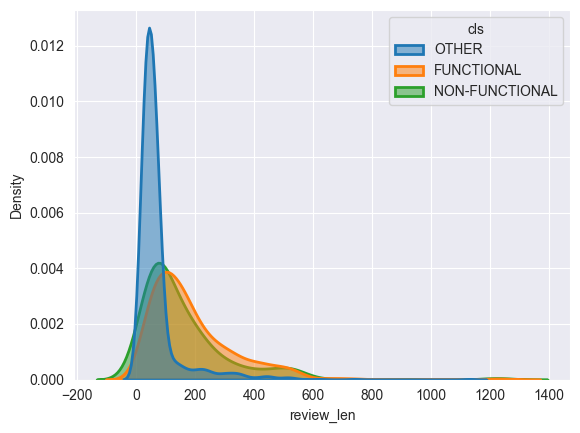

In [9]:
# review_len

plt.figure()
sb.kdeplot(data=data,
           x='review_len',
           hue='cls',
           fill=True,
           common_norm=False,
           # svaka kriva se normalizuje zasebno (povrsina = 1), pa se mogu porediti oblici raspodela bez obzira na to koliko je klasa velika
           alpha=0.5,
           linewidth=2)
plt.show()

# izdvaja bar jednu klasu od ostale dve -> znacajan prediktor

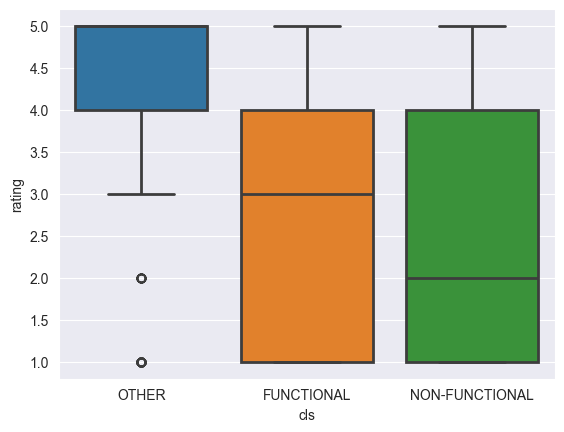

In [10]:
# rating

plt.figure()
# moze i ovde kdeplot
sb.boxplot(data=data,
           x='cls',
           y='rating',
           hue='cls',
           fill=True,
           linewidth=2,
           legend=False)
plt.show()

# medijane po klasama se razlikuju (4,3,2) -> rating je takodje znacajan prediktor

In [11]:
# zadrzavamo tri prediktora (rating, review_len, review) i izlaznu varijablu (cls)

data_sub = data[['rating', 'review_len', 'review', 'cls']]

data_sub.head()

,rating,review_len,review,cls
0,5,40,cute!!!! the game is just to cute!!!! :3,OTHER
1,4,41,? well its ok but not bad nor is it great,OTHER
2,1,60,? have no idea how to feed dragon and boooorrr...,OTHER
3,2,295,when i play games it reboots about every third...,FUNCTIONAL
4,5,43,love my dragon have fun! yahoooey! godbless,OTHER


## PRETPROCESIRANJE TEKSTA (spacy)

In [12]:
# ucitavanje pipeline-a
nlp_pipe = spacy.load('en_core_web_sm')

**NLP** (Natural Language Processing) je oblast koja omogucava racunaru da obradjuje i analizira ljudski jezik.
U ovom primeru review je tekst, ali klasifikator ocekuje numericke osobine, pa NLP sluzi kao most izmedju sirovog teksta i modela.

**spaCy** je Python biblioteka za obradu prirodnog jezika. Notebook ucitava model en_core_web_sm. To nije samo recnik, vec pipeline komponenti za obradu engleskog teksta -> nlp_pipe = spacy.load('en_core_web_sm')

**Tokenizacija** znaci razlaganje teksta na **tokene** – najcesce reci i znakove koje NLP sistem obradjuje kao zasebne jedinice.

**POS (Part of Speech)** je gramaticka kategorija tokena: npr. NOUN, VERB, ADJ, ADV, PRON, PROPN.
POS se u ovom notebooku prvenstveno koristi da pokaze šta spaCy zna o tekstu; sam klasifikacioni pipeline ne koristi POS oznaku kao posebnu numericku osobinu.

**Lema** je osnovni/dictionary oblik reci. freezes -> freeze, wasted -> waste. Lematizacijom razlicite gramaticke forme mogu biti predstavljene istom osnovnom recju.
Vazno: lema nije isto što i root/stem. Stemming mehanicki skracuje rec, dok lematizacija koristi lingvisticku analizu da dobije odgovarajuci osnovni oblik.

**Stop words** su veoma ceste reci koje se cesto uklanjaju jer nose malo diskriminativne informacije za zadatak.

#### PRVO DA MALO ISTRAZIMO SPACY

In [13]:
sample_review = data_sub.sample(random_state=RAND_STATE).review
sample_review_cls = data_sub.sample(random_state=RAND_STATE).cls

print(f"Recenzija:\n{sample_review.iloc[0]}")
print(f"\nKlasa:\n{sample_review_cls.iloc[0]}")

Recenzija:
freezes all de way not @all on my samsung ace. i wasted my data for nothing

Klasa:
FUNCTIONAL


In [14]:
sample_review = sample_review.iloc[0]

parsed_review = nlp_pipe(sample_review)
# nlp_pipe(text) vraca Doc objekat u kom je svaki token obogacen lingvistickim osobinama

token_text = [token.text for token in parsed_review]
token_pos = [token.pos_ for token in parsed_review]
token_lemma = [token.lemma_ for token in parsed_review]

pd.DataFrame(data=zip(token_text, token_pos, token_lemma), columns=['text', 'POS', 'lemma']).head()

,text,POS,lemma
0,freezes,VERB,freeze
1,all,PRON,all
2,de,X,de
3,way,ADV,way
4,not,PART,not


In [15]:
# STOP WORDS

spacy_stopwords = spacy.lang.en.stop_words.STOP_WORDS
# sve stop words u engleskom jeziku

print(f"Broj stop words-a: {len(spacy_stopwords)}\n")
print(f"Prvih 20:\n{', '.join(sorted(list(spacy_stopwords))[:20])}")

print(f"\nDa li je 'not' u spacy's stop words listi: {'Da' if 'not' in spacy_stopwords else 'Ne'}")

Broj stop words-a: 326

Prvih 20:
'd, 'll, 'm, 're, 's, 've, a, about, above, across, after, afterwards, again, against, all, almost, alone, along, already, also

Da li je 'not' u spacy's stop words listi: Da


#### KORISCENJE SPACY ZA PRETPROCESIRANJE SVIH REZENCIJA

In [16]:
def spacy_preprocessing(doc):
    # kreiranje tokena sa lingvistickim osobinama
    tokens = nlp_pipe(doc)
    # uklanjanje interpunkcija, praznina, brojeva i url
    tokens = [token for token in tokens
              if ((not token.is_punct) and (not token.is_space) and
                  (not token.like_num) and (not token.like_url))]
    # uklanjanje stop words (ostavljamo not)
    tokens = [token for token in tokens
              if ((not token.is_stop) or (token.lemma_.lower() == 'not'))]

    # pretvaranje tokena u lemme
    words = [token.lemma_ for token in tokens]

    # vracanje pretprocesuiranih reci
    return words

In [17]:
sample_tokens = spacy_preprocessing(sample_review)

print(f"Sample recenzija PRE pretprocesiranja:\n{sample_review}\n")
print(f"Sample recenzija POSLE pretprocesiranja:\n{' '.join(sample_tokens)}\n")

print(f"Broj tokena PRE pretprocesiranja: {len(parsed_review)}")
print(f"Broj tokena POSLE pretprocesiranja: {len(sample_tokens)}")

Sample recenzija PRE pretprocesiranja:
freezes all de way not @all on my samsung ace. i wasted my data for nothing

Sample recenzija POSLE pretprocesiranja:
freeze de way not @all samsung ace waste datum

Broj tokena PRE pretprocesiranja: 17
Broj tokena POSLE pretprocesiranja: 9


## TEKST TRANSFORMACIJA KORISCENJEM **BoW**

**Bag of Words (BoW)** je nacin predstavljanja teksta pomocu brojeva. Svaki dokument se predstavlja kao vektor brojeva, pri cemu svaki broj predstavlja **broj pojavljivanja odredjene reci iz recnika u tom dokumentu**.

Kod BoW pristupa **redosled reci se gubi** – posmatra se samo koje se reci pojavljuju i koliko puta. Zbog toga se metoda naziva „vreca reci“. Gubitak redosleda je jedno od glavnih ogranicenja ove metode.

Rezultat je **matrica** u kojoj:
* **redovi** predstavljaju dokumente,
* **kolone** predstavljaju reci iz recnika,
* **celije** predstavljaju broj pojavljivanja odredjene reci u odredjenom dokumentu.

Matrica je najcesce **retka (sparse)**, jer se vecina reci iz celog recnika ne pojavljuje u svakom dokumentu, pa se u vecini celija nalaze nule.

**CountVectorizer** iz biblioteke `sklearn` koristi se za pretvaranje tekstualnih dokumenata u BoW matricu. On na osnovu skupa dokumenata formira **recnik (vocabulary)**, a zatim za svaki dokument odredjuje koliko puta se svaka rec iz recnika pojavljuje.

`CountVectorizer` može da izvrsi i odredjene osnovne korake obrade teksta, kao sto je pretvaranje slova u mala slova i tokenizacija prema podrazumevanim pravilima. Takodje, mozemo mu proslediti **sopstvenu funkciju za tokenizaciju** pomocu argumenta `tokenizer`.

Ako nasa funkcija, pored tokenizacije, izvršava i dodatnu obradu teksta – na primer uklanjanje brojeva, URL-ova, znakova, stop reci ili lematizaciju – tada se ti koraci izvršavaju pre nego što `CountVectorizer` formira BoW reprezentaciju.

Proces tada mozemo posmatrati ovako:
**originalni tekst -> preprocessing/tokenizacija -> formiranje recnika -> brojanje pojavljivanja reci -> BoW matrica**

In [18]:
def create_count_vectorizer(ngrams=(1, 1), min_doc_freq=0.01, f_max=-1):
    vectoriser = CountVectorizer(
        tokenizer=spacy_preprocessing,  #umesto ugradjenog deljenja teksta, koristimo svoju funkciju
        token_pattern=None,  #kazemo da ne koristi regex
        ngram_range=ngrams,
        max_features=f_max if f_max > 0 else None,  # ogranicava recnik na n najcescih reci
        min_df=min_doc_freq  # rec ulazi u recnik samo ako se pojavljuje u najmanje _% dokumenta
    )

    return vectoriser

# ngram_range=(1,1): n-gram je niz od n uzastopnih reci. (1,1) znaci samo pojedinacne reci (unigrami). (1,2) bi dodalo i parove ("not work"), cime se delimicno vraca kontekst, ali se recnik jako povecava

In [19]:
vectorized_example = create_count_vectorizer()
vectorized_reviews = vectorized_example.fit_transform(data_sub.review)
pd.DataFrame(data=vectorized_reviews.toarray(), columns=vectorized_example.get_feature_names_out())

,ability,able,accurate,ad,add,allow,amazing,android,app,application,...,virus,want,way,weather,well,widget,will,wish,work,wow
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,0,0,0,0,0,0,0,1,0,0,...,2,0,0,0,0,0,0,0,0,0
2996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2997,0,0,0,0,0,0,0,0,1,0,...,1,0,0,0,0,0,0,0,0,0
2998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Kreiranje i testiranje **pipeline**-a za klasifikaciju teksta

Napravicemo klasifikator recenzija kao niz („**pipeline**“) od nekoliko povezanih komponenti, koristeci `Pipeline` klasu iz biblioteke `sklearn`.

**Pipeline** je pomocna klasa iz `sklearn` koja povezuje vise koraka obrade u jednu celinu. Mozemo ga zamisliti kao **proizvodnu traku za obradu podataka**:
* sirovi podaci predstavljaju ulaz,
* podaci se redom prosledjuju kroz niz koraka obrade (na primer ciscenje i transformacija podataka),
* na kraju dobijamo obucen model za klasifikaciju ili regresiju.

**Zasto koristimo pipeline?**
* **Cistiji i pregledniji kod** – svi koraci obrade i modela nalaze se na jednom mestu i lakse ih je odrzavati.
* **Sprecavanje curenja podataka (data leakage)** – pipeline obezbedjuje da se `fit()` i `transform()` koraci u procesu obrade pravilno izvrsavaju samo na podacima za obucavanje, cime se sprecava da informacije iz test skupa uticu na obucavanje modela.
* **Jednostavnije podesavanje hiperparametara** – mozemo istovremeno podesavati parametre razlicitih koraka celog procesa, ukljucujuci pretprocesiranje i sam model.

U nasem slucaju pipeline povezuje **CountVectorizer** i **Decision Tree**:

**tekst recenzije -> CountVectorizer -> BoW reprezentacija -> Decision Tree -> predvidjena klasa**


#### DELJENJE PODATAKA NA TRAIN I TEST SKUP

In [20]:
X = data_sub.drop(columns='cls')
y = data_sub.cls.values

In [21]:
# faktorizacija izlazne promenljive na 0 1 2 (Decision Tree moze da radi i sa tekstualnim klasama, ali se ovde klase kodiraju u numericki oblik radi lakseg rada
y_encodings, y_levels = pd.factorize(y)

# y_encodings - stvarne numericke oznake klasa: [0, 1, 2, 0, 2]
# y_levels - informacije o tome koji broj predstavlja koju originalnu klasu: ['other','functional', 'non-functional']
display(y_levels)
pd.Series(y_encodings).value_counts()

array(['OTHER', 'FUNCTIONAL', 'NON-FUNCTIONAL'], dtype=object)

0    1505
1    1097
2     398
Name: count, dtype: int64

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y_encodings,
                                                    test_size=0.2,
                                                    random_state=RAND_STATE,
                                                    stratify=y_encodings
                                                    )

## ColumnTransformer

`ColumnTransformer` omogucava da se **razlicite transformacije primene na razlicite kolone** skupa podataka.

U nasem skupu podataka imamo razlicite tipove podataka:
* `review` – tekstualna kolona
* `review_len` – numericka kolona koja predstavlja duzinu recenzije
* `rating` – numericka kolona koja predstavlja ocenu recenzije

Posto ove kolone nisu istog tipa, ne mozemo ih sve obraditi na isti nacin.

Tekstualna kolona `review` mora prvo da se pretvori u numericku reprezentaciju. Za to koristimo `CountVectorizer`, koji tekst pretvara u **Bag of Words** reprezentaciju. Svaka recenzija se na taj nacin predstavlja kao niz brojeva koji oznacavaju pojavljivanje reci iz vokabulara.

Numericke kolone, kao sto su `review_len` i `rating`, vec imaju numericke vrednosti i mogu se direktno proslediti modelu ili po potrebi dodatno transformisati.

Na ovaj nacin dobijamo jednu konacnu numericku reprezentaciju podataka koju `Decision Tree` moze da koristi za klasifikaciju.

`ColumnTransformer` je posebno koristan kod **heterogenih podataka**, odnosno skupova podataka koji sadrze razlicite tipove podataka, kao sto su tekstualne, numericke i kategorijske kolone.

Na primer, kategorijska kolona bi mogla da se obradjuje pomoću `OneHotEncoder`, dok bi se numericka kolona mogla skalirati pomoću odgovarajuceg transformatora.

**Vazno je razlikovati `ColumnTransformer` i `Pipeline`:**
* `ColumnTransformer` odredjuje **kako se obradjuju razlicite kolone**.
* `Pipeline` povezuje **vise koraka obrade u jedan redosled**.

#### KREIRANJE VECTORISER-A I COLUMN TRANSFORMER-a

In [23]:
# pravimo instancu count vectoriser-a, koju smo gore definisali
count_vectorizer = create_count_vectorizer()

column_transformer = ColumnTransformer(
    [('word_counts', count_vectorizer, 'review')],
    remainder='passthrough'
)

# [('ime_transformacije', transformator, kolona)]
# passthrough - sve kolone koje nismo posebno naveli samo prosledi dalje bez promene

#### KREIRANJE KLASIFIKATORA

In [24]:
# za klasifikaciju koristimo decision tree

classifier = DecisionTreeClassifier(random_state=RAND_STATE, min_impurity_decrease=0.001)

# min_impurity_decrease - kontrola grananja stabla

#### DEFINISANJE I TRENING PIPELINE-A

In [25]:
pipe = Pipeline([('vectorizer', column_transformer),
                 ('classifier', classifier)])
# saljemo naziv komponente i samu komponentu

pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('vectorizer', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('word_counts', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

#### PRISTUP ELEMENTIMA PIPELINE-a

In [26]:
pipe.named_steps
# vraca recnik strukture pipeline-a

{'vectorizer': ColumnTransformer(remainder='passthrough',
                   transformers=[('word_counts',
                                  CountVectorizer(min_df=0.01,
                                                  token_pattern=None,
                                                  tokenizer=<function spacy_preprocessing at 0x0000018AF6675E40>),
                                  'review')]),
 'classifier': DecisionTreeClassifier(min_impurity_decrease=0.001, random_state=1)}

In [27]:
# pristup pojedinacnoj komponenti
pipe.named_steps['classifier'].get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.001,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': 1,
 'splitter': 'best'}

### EVALUACIJA MODELA

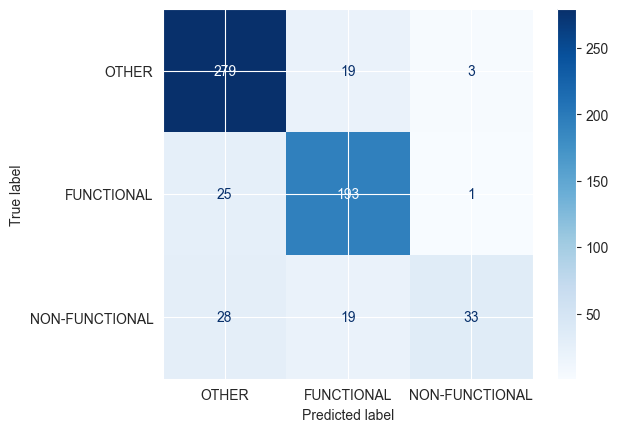

In [28]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay.from_estimator(
    pipe,
    X_test,
    y_test,
    display_labels=y_levels,
    cmap = 'Blues'
)

In [29]:
prediction_1 = pipe.predict(X_test)

report_1 = metrics.classification_report(y_true=y_test, y_pred=prediction_1)
print(report_1)

# support - broj pojavljivanja svake klase u y_true

# macro avg - prosek rezultata po klasama, pri cemu svaka klasa ima jednaku tezinu, nezavisno od broja njenih primera i zbog toga los rezultat na manjinskoj ili tezoj klasi znacajno utice na konacnu vrednost proseka

# weighted avg - prosek rezultata po klasama, pri cemu je rezultat svake klase ponderisan njenim support-om, odnosno brojem primera te klase, koristi se kada zelimo da ukupna uspesnost vise odrazava performanse na dominantnim klasama nego na retkim

              precision    recall  f1-score   support

           0       0.84      0.93      0.88       301
           1       0.84      0.88      0.86       219
           2       0.89      0.41      0.56        80

    accuracy                           0.84       600
   macro avg       0.86      0.74      0.77       600
weighted avg       0.85      0.84      0.83       600



#### BALANCED ACCURACY

S obzirom da smo vec utvrdili da dataset nije balansiran (podsetimo se da je vise od 50% rezencija klase OTHER), racunacemo i **balanced accuracy**.

Balanced accuracy se racuna kao zbir accuracy po klasama podeljen sa ukupnim brojem testnih uzoraka.

Koristimo kada zelimo da obezbedimo da model ne postize visok ukupni rezultat, a da pri tome lose klasifikuje manjinsku klasu.


In [30]:
display(f"Accuracy: {metrics.accuracy_score(y_test,prediction_1):0.4f}")
display(f"Balanced accuracy: {metrics.balanced_accuracy_score(y_test,prediction_1, adjusted=True):0.4f}")

# slucajni model - model koji nema nikakvo znanje i samo nasumicno bira klasu
# adjusted=True - postavlja njegov rezultat kao 0 kako bi se lakse procenilo koliko je nas model bolji od slucajnog pogadjanja

'Accuracy: 0.8417'

'Balanced accuracy: 0.6103'